# Clustering

## Summary of findings

Present a summary of your findings here, including the answers to the questions from the exercise sheet. Then present your code and additional findings below.

You may use sklearn’s `KMeans` for Lloyd’s algorithm, but you must implement k-Means++ and the coreset sampling procedure yourself.

## Clustering using Lloyd's algorithm

In [27]:
from PIL.ImageChops import difference
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.datasets import mnist
import numpy as np
import time
from sklearn.metrics import pairwise_distances_argmin_min

# Load MNIST or Fashion-MNIST
# (x_train, _), _ = mnist.load_data()
(x_train, _), _ = fashion_mnist.load_data() # use this line to load Fashion MNIST

# Flatten and scale images
X = x_train.reshape(len(x_train), -1)  # shape: (60000, 784)
X = StandardScaler().fit_transform(X)

4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [28]:
# K-Means clustering
kmeans = KMeans(n_clusters=10)
kmeans.fit(X)

# Output objective function value (inertia_)
print(f'K-Means objective (inertia): {kmeans.inertia_:.2f}')

K-Means objective (inertia): 26273800.22


## Implementation of $k$-Means++

In [45]:
def k_means_plus_plus(X, k):
  x = X[np.random.randint(0, X.shape[0])]
  T = [x]
  min_distances = np.full(X.shape[0], np.inf)
  while len(T) < k: # happens k times
    # calculate the distances to the newest center
    z = T[-1]
    new_distances = np.sum((X - z) ** 2, axis=1) # O(n*d)

    # find the cost(x, T) for all X
    # cost_x = np.min(cost_for_each_point, axis=0) # O(n*k)
    cost_x = np.minimum(min_distances, new_distances) # O(n)
    cost_T = np.sum(cost_x) # O(n)

    # randomly select a new point with the calculated probability
    sampled_index = np.random.choice(X.shape[0], p=(cost_x/cost_T)) # O(n)
    T.append(X[sampled_index])

    min_distances = cost_x
  return T


## Experimental Evaluation

### Running Lloyd's algorithm on coresets
1. Given your final clustering, how closely does the objective function value on the coreset match the objective function value on the entire dataset?

Running Lloyd's algorithm with clustering is up to 2 times worse than running on the entire dataset.

2. How many points do you need in the coreset to get good results (as a function of k)?

The best result is if we use the most amount of points. But we also need to account for the slow-down tha calculating the coresets bring.

3. Does this improve the overall running time?

If we only have a few coresets then yes but increasing the number of coresets too much will decrease the time enormously. It is only improved if the generation time of the coresets is smaller than the k-means takes on the entire set. In the plots we can see that it's barely worth it to run it with 10 coresets.

In [46]:
coreset_sizes = [0, 10, 20, 30, 40, 50, 100]
k_s = [3, 6, 10]
times_with_generation = [list() for _ in k_s]
times_without_generation = [list() for _ in k_s]
results = [list() for _ in k_s]

for size in coreset_sizes:
    for i, k in enumerate(k_s):
        print(f"Running coreset with size: {size} and k: {k}")
        kmeans = KMeans(n_clusters=k)
        if size == 0:
            start_time = time.perf_counter()
            kmeans.fit(X)
            times_without_generation[i].append(time.perf_counter() - start_time)
            times_with_generation[i].append(time.perf_counter() - start_time)
            results[i].append(kmeans.inertia_)
        else:
            start_time = time.perf_counter()
            coreset = k_means_plus_plus(X, size)
            after_generation_time = time.perf_counter()
            kmeans.fit(coreset)
            end_time = time.perf_counter()

            # calculate error
            learned_centers = kmeans.cluster_centers_
            closest_center_indices, distances = pairwise_distances_argmin_min(X, learned_centers)

            times_with_generation[i].append(end_time - start_time)
            times_without_generation[i].append(end_time - after_generation_time)
            results[i].append(np.sum(distances ** 2))
    size += corset_interval


Running coreset with size: 100 and k: 10


#### Plot

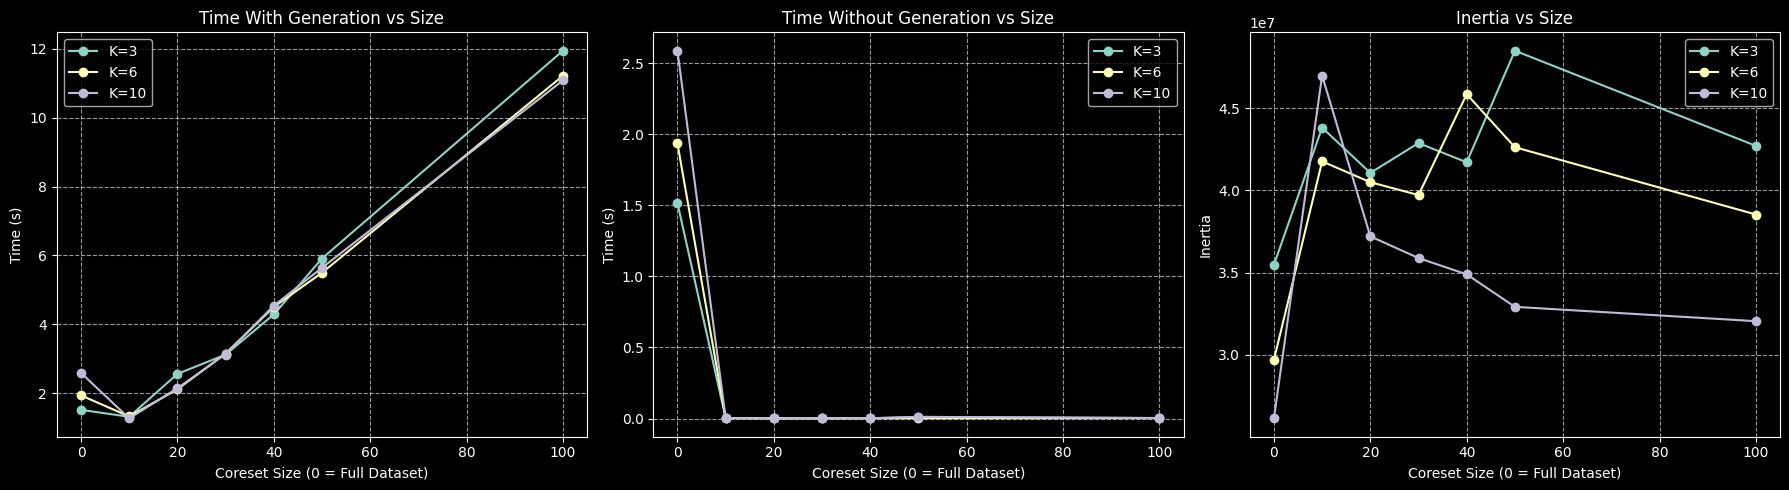

In [48]:
# --- PLOT SET 1: Metrics grouped by K ---
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))

for i, k in enumerate(k_s):
    ax = axes1[i]
    # Filter out NaNs (from when size < k) for clean plotting
    valid_idx = ~np.isnan(times_with_generation[i])
    sizes_valid = np.array(coreset_sizes)[valid_idx]

    ax.plot(sizes_valid, np.array(times_with_generation[i])[valid_idx], label='Time w/ Gen', marker='o', color='tab:blue')
    ax.plot(sizes_valid, np.array(times_without_generation[i])[valid_idx], label='Time w/o Gen', marker='s', color='tab:green')

    ax.set_title(f'Performance for K={k}')
    ax.set_xlabel('Coreset Size (0 = Full Dataset)')
    ax.set_ylabel('Time (seconds)')
    ax.grid(True, linestyle='--', alpha=0.6)

    # Plot Inertia on a twin Y-axis so the scale doesn't ruin the Time plot
    ax2 = ax.twinx()
    ax2.plot(sizes_valid, np.array(results[i])[valid_idx], label='Inertia', color='tab:red', marker='^', linestyle='--')
    ax2.set_ylabel('Inertia (Red)', color='tab:red')

    # Combine legends
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.tight_layout()
plt.show()

# --- PLOT SET 2: Comparing K's for each Metric ---
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

titles = ['Time With Generation vs Size', 'Time Without Generation vs Size', 'Inertia vs Size']
y_labels = ['Time (s)', 'Time (s)', 'Inertia']
data_lists = [times_with_generation, times_without_generation, results]

for metric_idx, (title, ylabel, data) in enumerate(zip(titles, y_labels, data_lists)):
    ax = axes2[metric_idx]
    for i, k in enumerate(k_s):
        valid_idx = ~np.isnan(data[i])
        sizes_valid = np.array(coreset_sizes)[valid_idx]
        ax.plot(sizes_valid, np.array(data[i])[valid_idx], label=f'K={k}', marker='o')

    ax.set_title(title)
    ax.set_xlabel('Coreset Size (0 = Full Dataset)')
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()